In [2]:
import numpy as np
import pandas as pd
import torch as T
import sqlite3
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

In [3]:
conn = sqlite3.connect(r"C:\Users\spear\projects\customer-lifetime\data\demo.db")
customers = pd.read_sql(
    """
    SELECT * 
    FROM CUSTOMERS
    """,
    conn
)


visits = pd.read_sql(
    """
    SELECT * 
    FROM VISITS
    """,
    conn
)


purchases = pd.read_sql(
    """
    SELECT a.purchase_id, a.visit_id, b.name, b.category, a.quantity
    FROM PURCHASES as a
    LEFT JOIN
    PRODUCTS as b
    ON
    a.product_id=b.product_id
    
    """,
    conn
)

features = pd.read_sql(
    """
    SELECT * 
    FROM customer_features
    """, 
    conn)

features_wide = features.pivot(index="customer_id", columns="feature_name", values="feature_value")
customers_descriptive = customers.merge(features_wide, on="customer_id", how="left")
visits["visit_date"] = pd.to_datetime(visits["visit_date"])
customers_descriptive["first_visit_date"] = pd.to_datetime(customers["first_visit_date"])
visit_counts = visits.groupby("customer_id").size().rename("n_visits")
customers_descriptive = customers_descriptive.merge(visit_counts, on="customer_id", how="left")
customers_descriptive["churned"] = (customers_descriptive["n_visits"] == 1).astype(int)
conn.close()

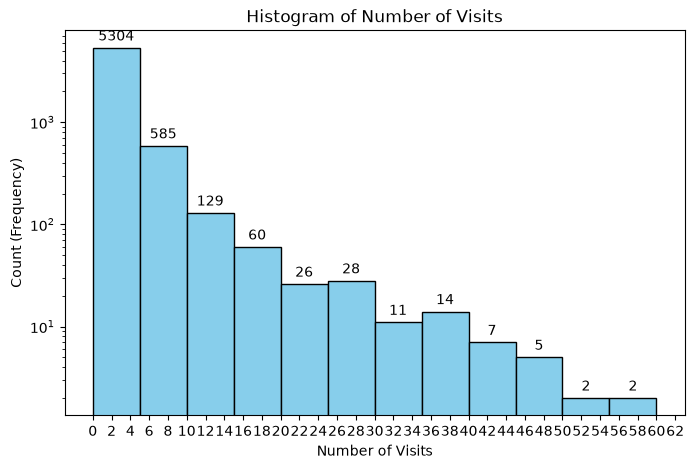

In [4]:
df = visits.groupby('customer_id').size().reset_index(name="Number of Visits")

num_visits = df.groupby('Number of Visits').size().reset_index(name='Number of Subjects')
num_subjects = len(customers)
bin_width = 5
sample_mean = df['Number of Visits'].mean()
sample_var = np.var(df['Number of Visits'])
max_num_visits = df['Number of Visits'].max()
adjusted_max_num_visits = bin_width * np.ceil((max_num_visits+1)/5)-1

df=visits.groupby('customer_id',as_index=False).size().rename(columns={"size":"Number of Visits"})
# Create the histogram
plt.figure(figsize=(8, 5))

# 2. Create the histogram (capture the 'bars' container object)
counts, bins, bars = plt.hist(df["Number of Visits"], bins=np.arange(0,adjusted_max_num_visits,5), edgecolor="black", color="skyblue", log=True)
# 3. Automatically add counts above the bars
plt.bar_label(bars, padding=3)
# Add formatting details
plt.title("Histogram of Number of Visits")
plt.xlabel("Number of Visits")
plt.ylabel("Count (Frequency)")
plt.xticks(np.arange(0,adjusted_max_num_visits,2))

# Display the plot
plt.show()

In [5]:
counts, edges = np.histogram(df['Number of Visits'],bins=np.arange(0,df['Number of Visits'].max(),5))
df['Number of Visits'].describe()

count    6173.000000
mean        2.928884
std         4.468689
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        60.000000
Name: Number of Visits, dtype: float64

In [6]:
#Exploring a Poisson Distributio with given sample mean
visits_pmf = stats.poisson.pmf(np.arange(0,adjusted_max_num_visits),1/sample_mean)
visits_pmf = np.append(visits_pmf,1-visits_pmf.sum())
expected_visits = visits_pmf * num_subjects
binned_expected_visits=expected_visits.reshape(-1,5).sum(axis=1)
for i,count in enumerate(binned_expected_visits):
    min_cust = 1 + 5*i
    max_cust = 5 + 5*i
    print(f"{count:.0f} customers expected with between {min_cust} and {max_cust} visits")
    if count<1:
        break
print(f"Sample Mean: {sample_mean:.2f}")
print(f"Sample Variance: {sample_var:.2f}")
print(f"Dispersion Index: {sample_var/sample_mean:.2f}")

6173 customers expected with between 1 and 5 visits
0 customers expected with between 6 and 10 visits
Sample Mean: 2.93
Sample Variance: 19.97
Dispersion Index: 6.82


A poisson distribution with our sample mean wouldn't populate even the second bin. 

Moreover, a poisson distribution would have dispersion index $\approx1$

Poisson distributions form a subset of negative binomial distributions.  We can perform a *likelihood ratio test* which also suggests these data are not poisson-distributed


In [7]:
#Sum log-likelihoods of the data given a poisson distribution with mean equal to the sample mean
ll_poisson = np.sum(stats.poisson.logpmf(df['Number of Visits'], sample_mean))

#Method of Momemnts estimates of p and n 
p_nb = sample_mean / sample_var
n_nb = (sample_mean ** 2) / (sample_var - sample_mean)
ll_nb = np.sum(stats.nbinom.logpmf(df['Number of Visits'], n_nb, p_nb))
lrt_stat = -2 * (ll_poisson - ll_nb)

#df=1 because there is one more parameter in the negative binomial distribution
p_value = stats.chi2.sf(lrt_stat, df=1)

print(f"LRT Statistic: {lrt_stat:.4f}")
print(f"P-value: {p_value:.4e}")

LRT Statistic: 6415.7449
P-value: 0.0000e+00


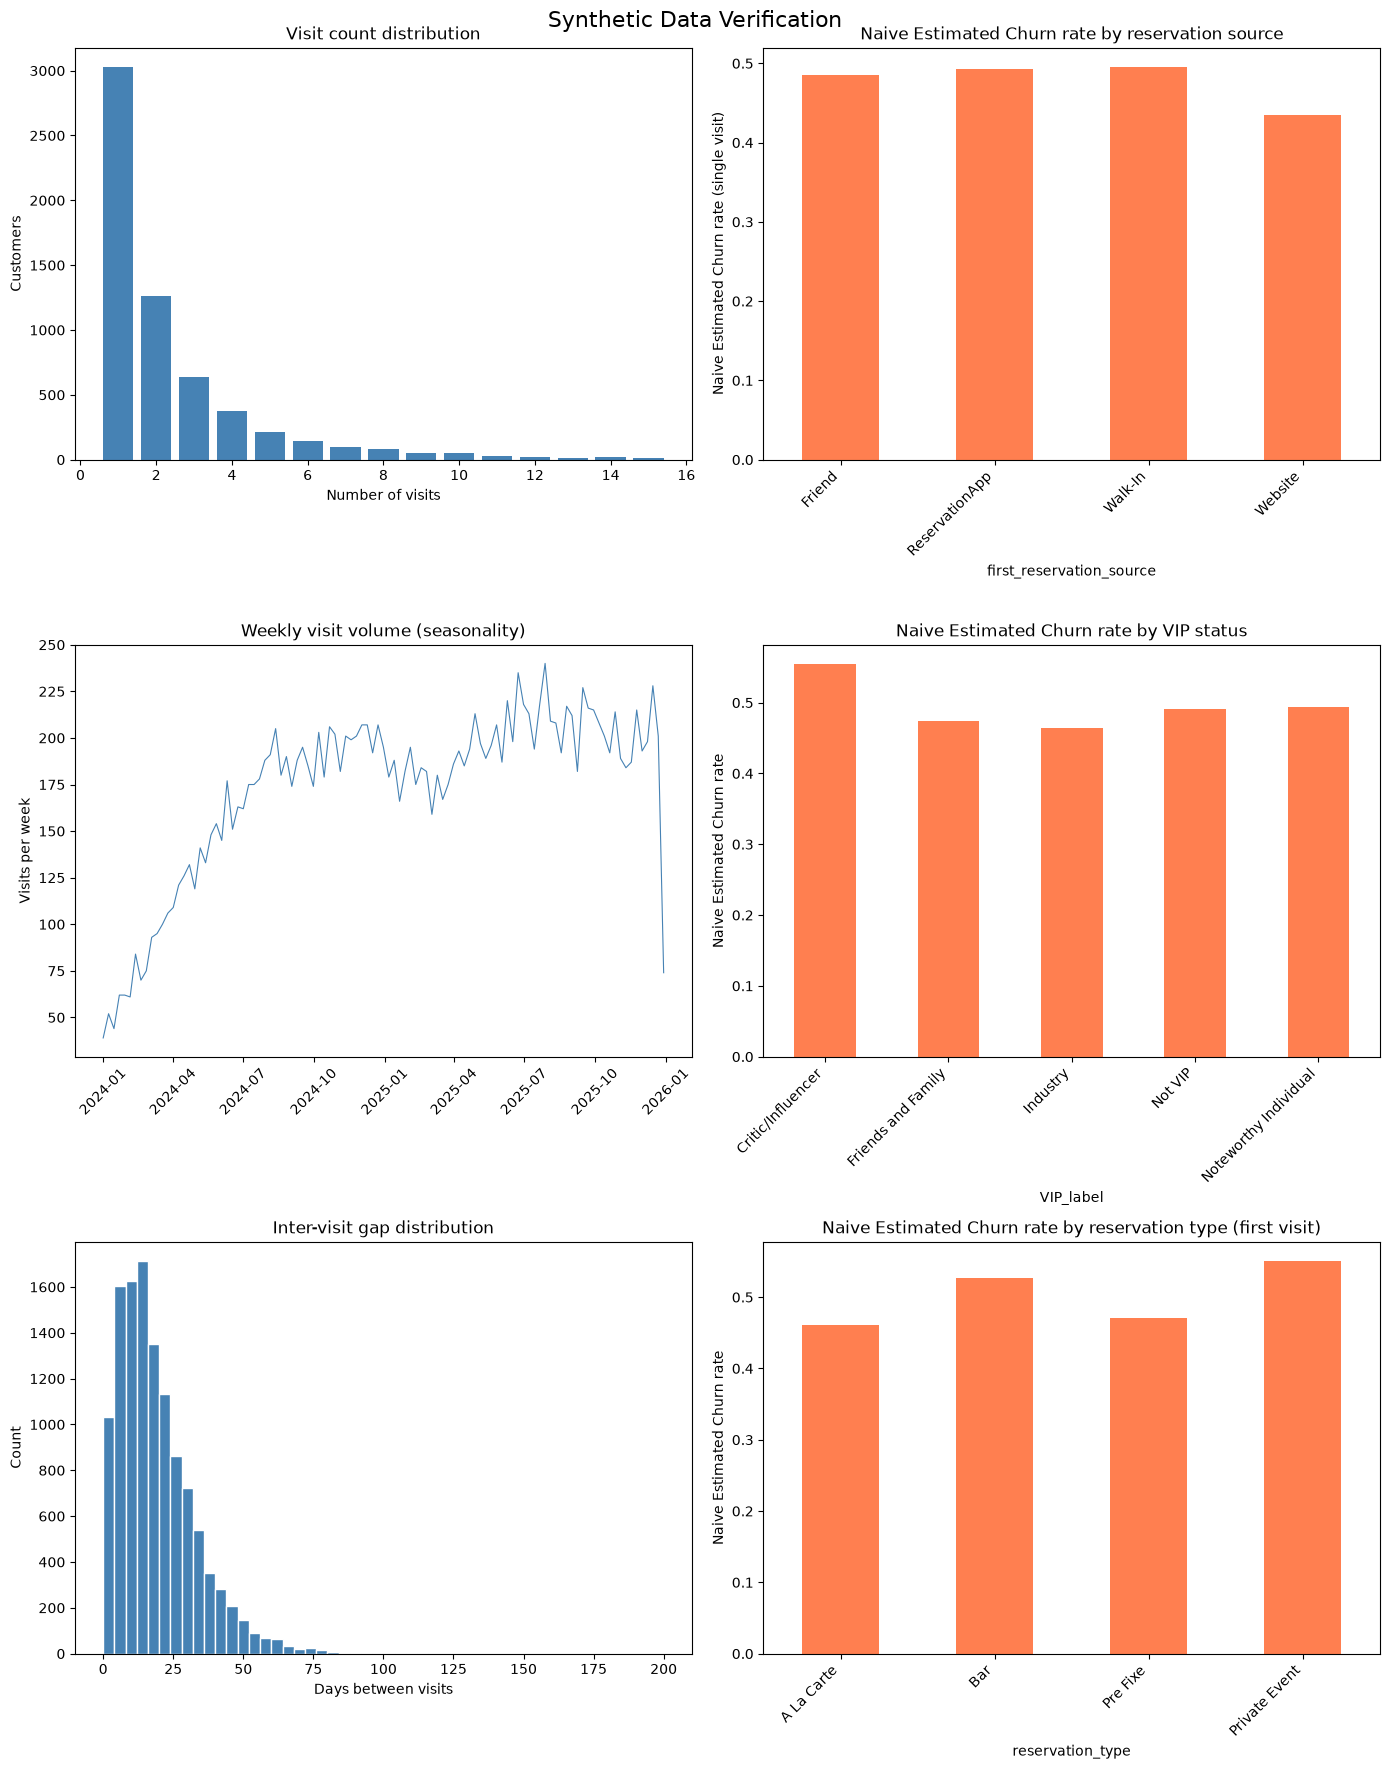

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(14, 18))
fig.suptitle("Synthetic Data Verification", fontsize=16, y=0.98)

# 1. Visit count distribution
ax = axes[0, 0]
vc = customers_descriptive["n_visits"].value_counts().sort_index()
ax.bar(vc.index[:15], vc.values[:15], color="steelblue")
ax.set_xlabel("Number of visits")
ax.set_ylabel("Customers")
ax.set_title("Visit count distribution")

# 2. Estimated Churn/cure rate by first reservation
ax = axes[0, 1]
churn_by_src = customers_descriptive.groupby("first_reservation_source")["churned"].mean()
churn_by_src.plot.bar(ax=ax, color="coral")
ax.set_ylabel("Naive Estimated Churn rate (single visit)")
ax.set_title("Naive Estimated Churn rate by reservation source")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

# 5. Visits per week over time (seasonality check)
ax = axes[1, 0]
visits["week"] = visits["visit_date"].dt.to_period("W").apply(lambda r: r.start_time)
weekly = visits.groupby("week").size()
ax.plot(weekly.index, weekly.values, linewidth=0.8, color="steelblue")
ax.set_ylabel("Visits per week")
ax.set_title("Weekly visit volume (seasonality)")
ax.tick_params(axis="x", rotation=45)

# 6. Estimated Churn rate by VIP status
ax = axes[1, 1]
customers_descriptive["VIP_label"] = customers_descriptive["VIP"].fillna("Not VIP")
churn_by_vip = customers_descriptive.groupby("VIP_label")["churned"].mean()
churn_by_vip.plot.bar(ax=ax, color="coral")
ax.set_ylabel("Naive Estimated Churn rate")
ax.set_title("Naive Estimated Churn rate by VIP status")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

# 7. Inter-visit gap distribution (returning customers only)
ax = axes[2, 0]
multi = visits[visits["customer_id"].isin(customers_descriptive[customers_descriptive["n_visits"] > 1]["customer_id"])]
multi = multi.sort_values(["customer_id", "visit_date"])
multi["gap_days"] = multi.groupby("customer_id")["visit_date"].diff().dt.days
gaps = multi["gap_days"].dropna()
ax.hist(gaps, bins=50, range=(0, 200), color="steelblue", edgecolor="white")
ax.set_xlabel("Days between visits")
ax.set_ylabel("Count")
ax.set_title("Inter-visit gap distribution")

# 8. Churn rate by reservation type
ax = axes[2, 1]
visit_first = visits.sort_values("visit_date").drop_duplicates("customer_id", keep="first")
visit_first = visit_first.merge(customers_descriptive[["customer_id","churned"]], on="customer_id")
churn_by_res = visit_first.groupby("reservation_type")["churned"].mean()
churn_by_res.plot.bar(ax=ax, color="coral")
ax.set_ylabel("Naive Estimated Churn rate")
ax.set_title("Naive Estimated Churn rate by reservation type (first visit)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig(r"C:\Users\spear\projects\customer-lifetime\data\eda_verification.png")
plt.show()

The estimated churn rates are "naive" because they assume that guests with 1 visit have churned - this isn't strictly true.  They may just not have returned yet.  The value of a survival analysis approach is precisely that it allows us to account for this possibility.  Even so - the visualizations above confirm that the method we are using to estimate churn does in fact lead to discernible differences between groups.

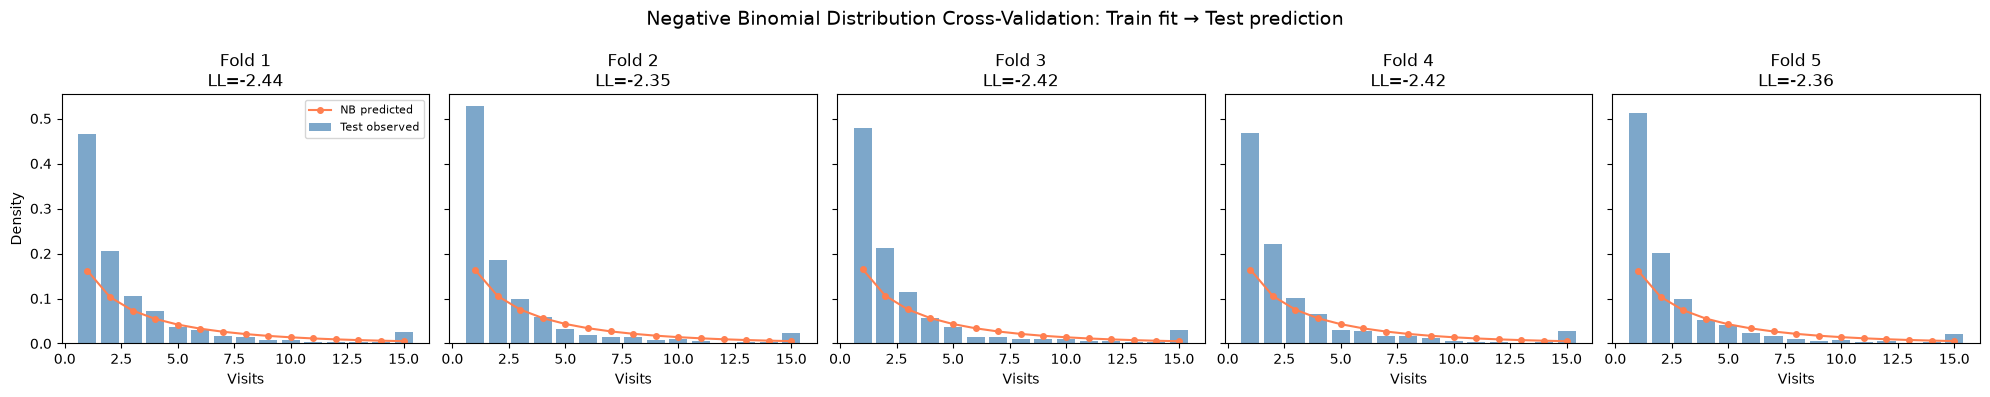


 fold   mean_ll        chi2   kl_div
    1 -2.440062  976.526519 0.685497
    2 -2.352918 1209.503990 0.726614
    3 -2.415014 1086.250702 0.698153
    4 -2.417854 1020.752604 0.690621
    5 -2.355962 1158.762907 0.726901

Averages:  LL=-2.396  Chi2=1090.4  KL=0.7056


In [9]:
y = customers_descriptive["n_visits"].values

kf = KFold(n_splits=5, shuffle=True, random_state=42)

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
fig.suptitle("Negative Binomial Distribution Cross-Validation: Train fit → Test prediction", fontsize=14)

max_day = 15
fold_results = []

for fold, (train_idx, test_idx) in enumerate(kf.split(y)):
    y_train, y_test = y[train_idx], y[test_idx]

    # Fit on train (method of moments)
    mu = y_train.mean()
    var = y_train.var()
    p = mu / var
    n = (mu ** 2) / (var - mu)

    # Predicted PMF
    k_range = np.arange(1, max_day + 1)
    nb_pmf = stats.nbinom.pmf(k_range, n, p)

    # Observed test distribution
    test_freq = np.bincount(np.clip(y_test, 0, max_day), minlength=max_day+1)[1:max_day+1]
    test_density = test_freq / len(y_test)

    # ── Evaluation metrics ───────────────────────────────────────
    # 1. Mean log-likelihood per test observation
    mean_ll = stats.nbinom.logpmf(y_test, n, p).mean()

    # 2. Chi-squared statistic: sum((observed - expected)^2 / expected)
    expected_counts = nb_pmf * len(y_test)
    # Avoid division by zero for bins with near-zero expected
    mask = expected_counts > 1
    chi2 = np.sum((test_freq[mask] - expected_counts[mask])**2 / expected_counts[mask])

    # 3. KL divergence (observed || predicted), only where both > 0
    kl_mask = (test_density > 0) & (nb_pmf > 0)
    kl_div = np.sum(test_density[kl_mask] * np.log(test_density[kl_mask] / nb_pmf[kl_mask]))

    fold_results.append({"fold": fold+1, "mean_ll": mean_ll, "chi2": chi2, "kl_div": kl_div})

    # Plot
    ax = axes[fold]
    ax.bar(k_range, test_density, color="steelblue", alpha=0.7, label="Test observed")
    ax.plot(k_range, nb_pmf, "o-", color="coral", markersize=4, label="NB predicted")
    ax.set_title(f"Fold {fold+1}\nLL={mean_ll:.2f}")
    ax.set_xlabel("Visits")
    if fold == 0:
        ax.set_ylabel("Density")
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("nb_cv_simple.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary table
results_df = pd.DataFrame(fold_results)
print("\n" + results_df.to_string(index=False))
print(f"\nAverages:  LL={results_df.mean_ll.mean():.3f}  "
      f"Chi2={results_df.chi2.mean():.1f}  "
      f"KL={results_df.kl_div.mean():.4f}")

The negative binomial model still fails - right-censoring places far too much weight on the left side of the distribution. 

Survival Analysis is meant to handle right-censoring.  

In biostatistics, the Kaplan Meier curve is used to model this behavior.  For a moment, instead of asking about the number of visits per customer, let's instead ask how long it would take for a given customer to return.  For a momeent, we'll treat a customer's repeat visits as independent.

Total intervals: 18080
  Observed returns: 11907
  Censored:         6173
  Median gap (observed): 15 days


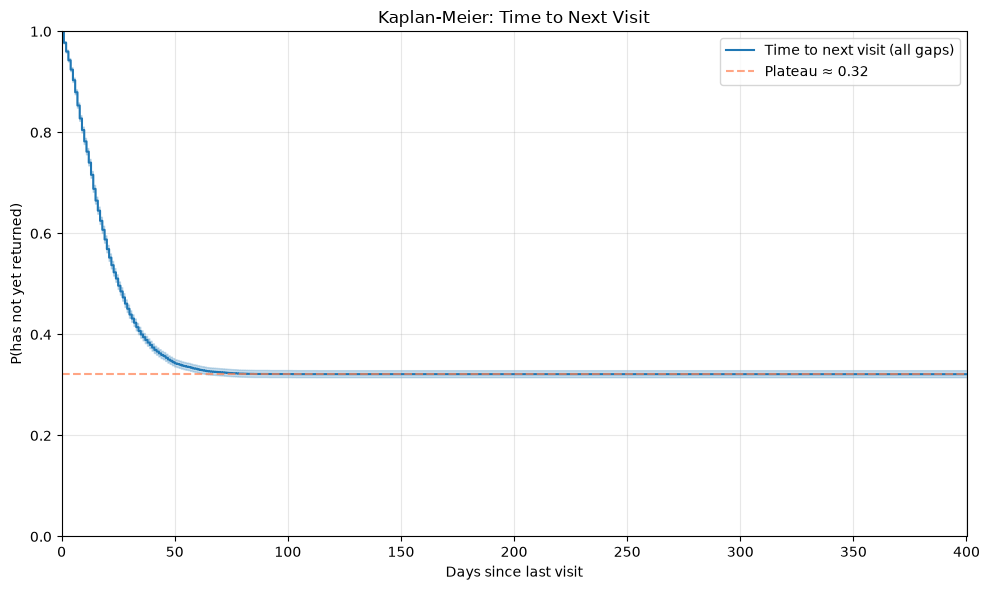


KM plateau (cure fraction estimate): 0.321
This is the fraction of visit-gaps where the customer never returned.


In [10]:
from lifelines import KaplanMeierFitter


datacutdt = pd.Timestamp("2025-12-31")


# ── Build gap-time dataset ───────────────────────────────────────
# Each row: one inter-visit interval
#   duration = days between visits (or days from last visit to end of observation)
#   event    = 1 if they returned, 0 if censored (no next visit observed)

records = []
for cid, grp in visits.groupby("customer_id"):
    dates = grp["visit_date"].sort_values().tolist()

    for i in range(len(dates)):
        if i < len(dates) - 1:
            # Observed return
            gap = (dates[i + 1] - dates[i]).days
            records.append({"customer_id": cid, "visit_num": i + 1,
                            "duration": gap, "event": 1})
        else:
            # Censored: last visit to end of observation
            gap = (datacutdt - dates[i]).days
            records.append({"customer_id": cid, "visit_num": i + 1,
                            "duration": gap, "event": 0})

gaps = pd.DataFrame(records)
print(f"Total intervals: {len(gaps)}")
print(f"  Observed returns: {gaps['event'].sum()}")
print(f"  Censored:         {(gaps['event'] == 0).sum()}")
print(f"  Median gap (observed): {gaps.loc[gaps['event']==1, 'duration'].median():.0f} days")

# ── Fit KM ───────────────────────────────────────────────────────
kmf = KaplanMeierFitter()
kmf.fit(gaps["duration"], event_observed=gaps["event"],
        label="Time to next visit (all gaps)")

fig, ax = plt.subplots(figsize=(10, 6))
kmf.plot_survival_function(ax=ax, ci_show=True)

ax.set_xlabel("Days since last visit")
ax.set_ylabel("P(has not yet returned)")
ax.set_title("Kaplan-Meier: Time to Next Visit")
ax.set_xlim(0, 400)
ax.set_ylim(0,1)
ax.axhline(y=kmf.survival_function_.iloc[-1].values[0], color="coral",
           linestyle="--", alpha=0.7, label=f"Plateau ≈ {kmf.survival_function_.iloc[-1].values[0]:.2f}")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("km_gap_time.png", dpi=150, bbox_inches="tight")
plt.show()

# The plateau is your cure fraction estimate — the proportion of
# gaps that never end (i.e., the customer never comes back).
print(f"\nKM plateau (cure fraction estimate): "
      f"{kmf.survival_function_.iloc[-1].values[0]:.3f}")
print("This is the fraction of visit-gaps where the customer never returned.")

Traditional KM-estimation assumes all censoring is non-informative.  That is, customers who haven't returned in 1000 days are just as likely to return tomorrow as they were 1 day after their visit.  Regardless the above curve shows a remarkably stable plateau.  In particular, this plateau is much lower than our "naively" estimated churn rates.

In a traditional KM analysis we'd read this plateau as a suggestion that the "baseline hazard" approaches 0 after a certain number of days - that a customer who hasn't come back after about 75 days won't come back at all. 

However, this interpretation leads to an incorrect assumption that the "true" churn rate is 0.317, the plateau height.  Because of how the KM estimator is computed, and because censoring times (i.e. time from last visit to the end of the observation window) are approximately uniformly distributed among potential times (see visualization below), this plateau is roughly the proportion of censored visits.  Because of how we built our dataset, assuming each interval was intependent, this is precisely the reciprocal of the average number of visits per subject - which isn't the true churn rate.

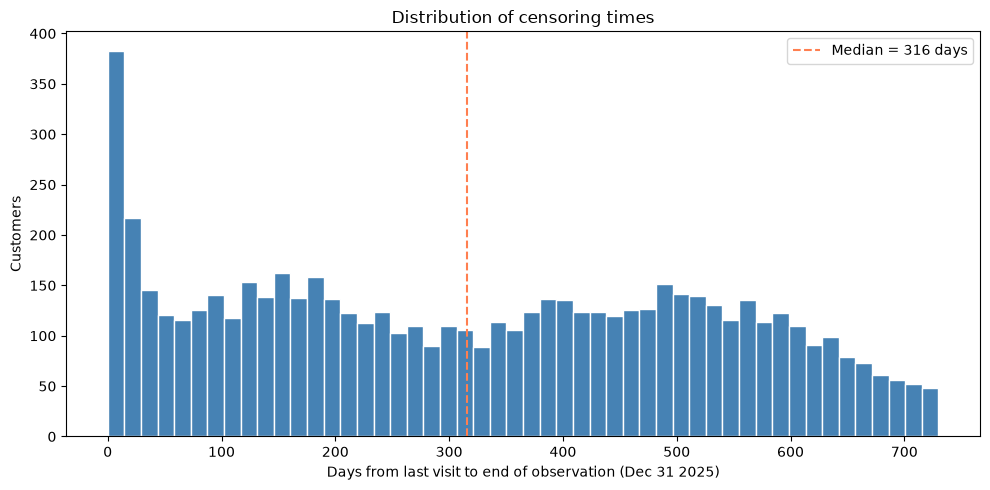

In [11]:
#Except for a spike close to 0 due to very recent customers, 
#censoring times are approximately uniformly distributed, with some sinusoidal behavior from seasonality
last_visits = gaps.groupby('customer_id').last()['duration']
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(last_visits, bins=50, color="steelblue", edgecolor="white")
ax.set_xlabel("Days from last visit to end of observation (Dec 31 2025)")
ax.set_ylabel("Customers")
ax.set_title("Distribution of censoring times")
ax.axvline(last_visits.median(), color="coral",
           linestyle="--", label=f'Median = {last_visits.median():.0f} days')
ax.legend()
plt.tight_layout()
plt.savefig("censoring_times.png", dpi=150, bbox_inches="tight")
plt.show()

Instead of using traditional KM estimation, we'll attempt to estimate the "true" underlying churn rates using modern machine learning techniques.

In [12]:
import sqlite3
import pandas as pd

conn = sqlite3.connect(r"C:\Users\spear\projects\customer-lifetime\data\demo.db")
visits = pd.read_sql("SELECT * FROM visits", conn)
conn.close()

visits["visit_date"] = pd.to_datetime(visits["visit_date"])
visits = visits.sort_values(["customer_id", "visit_date"]).reset_index(drop=True)

bad = []
for cid, group in visits.groupby("customer_id"):
    dates = group["visit_date"].tolist()
    vids = group["visit_id"].tolist()
    for i in range(1, len(dates)):
        if dates[i] <= dates[i-1]:
            bad.append({
                "customer_id": cid,
                "visit_id_prev": vids[i-1],
                "visit_id_curr": vids[i],
                "date_prev": dates[i-1],
                "date_curr": dates[i],
                "same_day": dates[i] == dates[i-1],
            })

bad_df = pd.DataFrame(bad)
print(f"Total violations: {len(bad_df)}")
if len(bad_df) > 0:
    print(f"Same-day: {bad_df['same_day'].sum()}")
    print(f"Backward: {(~bad_df['same_day']).sum()}")
    print()
    print(bad_df.head(20))

Total violations: 0


In [13]:
visits.loc[visits['customer_id']==437]

,visit_id,customer_id,visit_date,party_size,reservation_type,special_offer_category,day_of_week,partial_full_discount,discount_reason
1518,654,437,2024-03-16,4,A La Carte,None,Saturday,None,None
1519,825,437,2024-03-24,10,Private Event,None,Sunday,None,None
1520,1140,437,2024-04-09,6,Pre Fixe,None,Tuesday,None,None
1521,2356,437,2024-06-10,4,A La Carte,None,Monday,None,None
1522,2573,437,2024-06-17,6,A La Carte,None,Monday,None,None
1523,3193,437,2024-07-20,10,Private Event,None,Saturday,None,None
1524,3433,437,2024-07-28,4,A La Carte,None,Sunday,None,None
1525,3785,437,2024-08-05,3,Pre Fixe,None,Monday,None,None


C:\Users\spear\AppData\Local\Temp\ipykernel_40504\2236547932.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  visits_trunc["week"] = visits_trunc["visit_date"].dt.to_period("W").apply(lambda r: r.start_time)


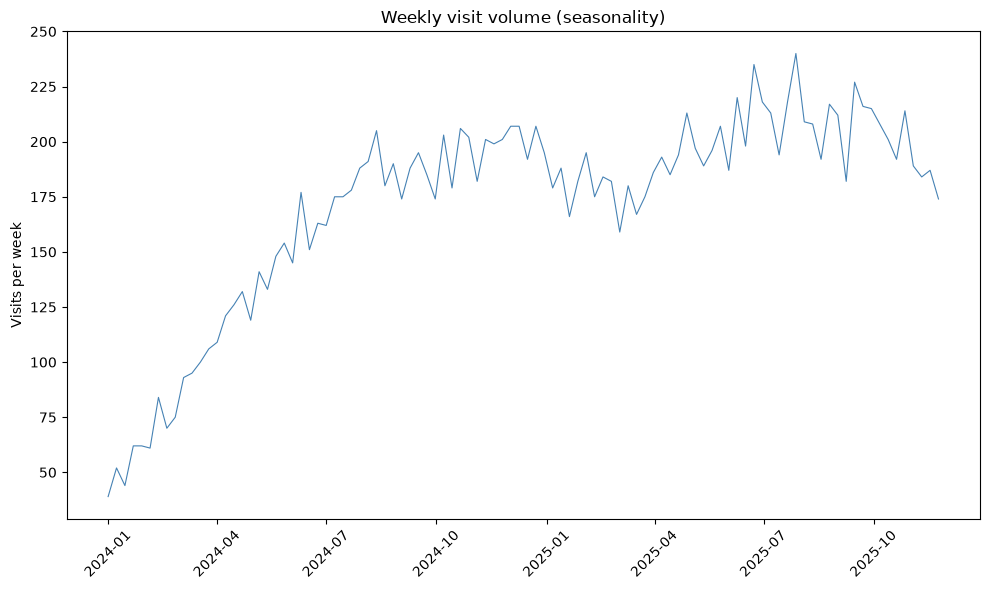

In [21]:
# 5. Visits per week over time (seasonality check)
fig, ax = plt.subplots(figsize=(10, 6))
visits_trunc = visits.loc[visits['visit_date']<'2025-11-30']
visits_trunc["week"] = visits_trunc["visit_date"].dt.to_period("W").apply(lambda r: r.start_time)
weekly = visits_trunc.groupby("week").size()
ax.plot(weekly.index, weekly.values, linewidth=0.8, color="steelblue")
ax.set_ylabel("Visits per week")
ax.set_title("Weekly visit volume (seasonality)")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("churn_equilibrium", dpi=150, bbox_inches="tight")
plt.show()

